# Разбор 3-way гибрида — запросы с AP=0

Анализируем ошибки лучшего на данный момент базового ретривера — **3-way гибрида**
(BM25 + RoSBERTa + e5-large, RRF), MAP@10 = **0.5189** на calibration.

Фокус — запросы с **AP@10 = 0** (ни одной правильной статьи в топ-10): сколько их,
и главное — это провал **поиска** (нужной статьи нет даже среди кандидатов) или
провал **ранжирования** (статья найдена, но стоит ниже 10-й позиции).

> Предсказания (топ-50) посчитаны заранее под `torch_env` и сохранены в
> `.emb_cache/hybrid_calib_preds50.pkl`, чтобы этот ноутбук не тянул тяжёлые модели.
> Регенерация: `"<torch_env>/python.exe"` строит `Hybrid().fit(arts).rank(cal, k=50)`.

In [1]:
import sys, pickle
sys.path.insert(0, "..")           # чтобы импортировать пакет src

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import EMB_CACHE
from src.data import load_articles, load_calibration, build_truth
from src.metrics import average_precision_at_k

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
pd.set_option("display.max_colwidth", 60)

articles = load_articles()
calibration = load_calibration()
truth = build_truth(calibration)
id2title = dict(zip(articles["article_id"], articles["title"]))
q2text = dict(zip(calibration["query_id"], calibration["query_text"]))

data = pickle.load(open(EMB_CACHE / "hybrid_calib_preds50.pkl", "rb"))
preds50 = {int(k): v for k, v in data["preds50"].items()}   # топ-50 кандидатов
ap = {int(k): v for k, v in data["ap"].items()}             # AP@10 по запросу
print("запросов:", len(ap), "| MAP@10:", round(np.mean(list(ap.values())), 4))

запросов: 500 | MAP@10: 0.5189


## 1. Обзор: распределение AP@10

MAP@10:            0.5189
recall@10:         0.8440
запросов AP=0:     46 (9.2%)
запросов AP=1:     132 (26.4%)


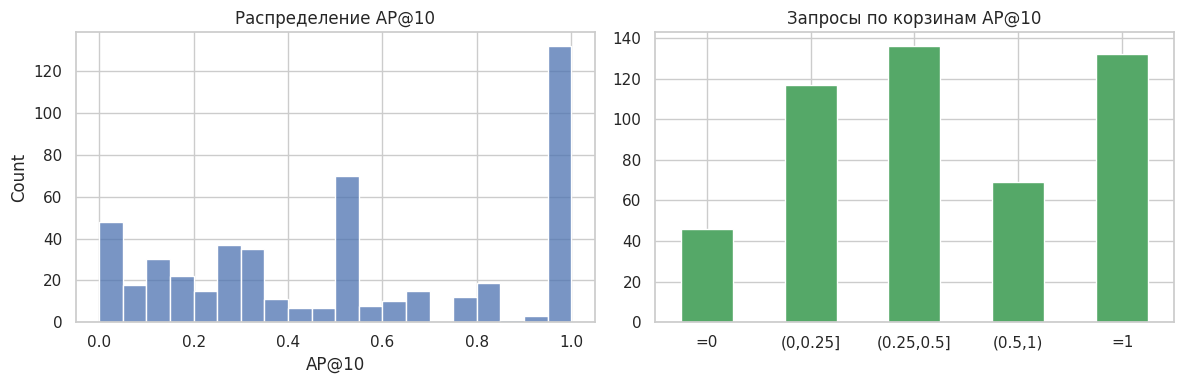

In [2]:
K = 10
recall10 = np.mean([len(set(preds50[q][:K]) & truth[q]) / len(truth[q]) for q in truth])
n_zero = sum(1 for v in ap.values() if v == 0.0)
n_perfect = sum(1 for v in ap.values() if v == 1.0)

print(f"MAP@10:            {np.mean(list(ap.values())):.4f}")
print(f"recall@10:         {recall10:.4f}")
print(f"запросов AP=0:     {n_zero} ({n_zero/len(ap)*100:.1f}%)")
print(f"запросов AP=1:     {n_perfect} ({n_perfect/len(ap)*100:.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(list(ap.values()), bins=20, ax=ax[0], color="#4C72B0")
ax[0].set_title("Распределение AP@10"); ax[0].set_xlabel("AP@10")
# доля запросов по «корзинам» качества
bins = pd.cut(pd.Series(ap), [-0.01, 0.0, 0.25, 0.5, 0.999, 1.0],
              labels=["=0", "(0,0.25]", "(0.25,0.5]", "(0.5,1)", "=1"])
bins.value_counts().reindex(["=0","(0,0.25]","(0.25,0.5]","(0.5,1)","=1"]).plot.bar(
    ax=ax[1], color="#55A868"); ax[1].set_title("Запросы по корзинам AP@10")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 2. AP=0: провал поиска или ранжирования?

Ключевой разрез. Для каждого запроса с AP=0 смотрим, есть ли правильная статья
среди **50 кандидатов** гибрида:

- **provал ранжирования** — правильная статья *есть* в топ-50, но не попала в топ-10
  (нужно поднять её выше → цель для reranker'а / лучших весов);
- **провал поиска** — правильной статьи нет даже в топ-50 (кандидаты её не содержат
  → нужно чинить recall, ранжирование не поможет).

In [3]:
zero_qids = [q for q in ap if ap[q] == 0.0]

rows = []
for q in zero_qids:
    gt = truth[q]
    in50 = gt & set(preds50[q])            # правильные среди 50 кандидатов
    # позиция лучшей найденной правильной статьи (1-based), если она есть
    best_rank = min([preds50[q].index(g) + 1 for g in in50], default=None)
    rows.append({"query_id": q, "n_gt": len(gt),
                 "gt_в_топ50": len(in50),
                 "тип": "ранжирование" if in50 else "поиск",
                 "ранг_лучшей_gt": best_rank})
zero = pd.DataFrame(rows)

print("Разбивка запросов с AP=0:")
print(zero["тип"].value_counts())
print()
print("Из провалов ранжирования — на какой позиции стоит лучшая правильная статья:")
print(zero.loc[zero["тип"] == "ранжирование", "ранг_лучшей_gt"]
      .value_counts().sort_index())

Разбивка запросов с AP=0:
тип
ранжирование    36
поиск           10
Name: count, dtype: int64

Из провалов ранжирования — на какой позиции стоит лучшая правильная статья:
ранг_лучшей_gt
11.0    7
12.0    1
13.0    3
14.0    4
15.0    3
16.0    2
17.0    3
18.0    1
21.0    1
22.0    1
24.0    1
27.0    1
35.0    1
36.0    1
37.0    1
44.0    1
46.0    1
49.0    2
50.0    1
Name: count, dtype: int64


In [4]:
# наглядно: сколько AP=0 «спасается», если бы мы дотянули топ-K глубже
for cut in (10, 15, 20, 30, 50):
    saved = sum(1 for q in zero_qids if truth[q] & set(preds50[q][:cut]))
    print(f"правильная статья попадает в топ-{cut:>2}: {saved:3d} / {len(zero_qids)} запросов с AP=0")

правильная статья попадает в топ-10:   0 / 46 запросов с AP=0
правильная статья попадает в топ-15:  18 / 46 запросов с AP=0
правильная статья попадает в топ-20:  24 / 46 запросов с AP=0
правильная статья попадает в топ-30:  28 / 46 запросов с AP=0
правильная статья попадает в топ-50:  36 / 46 запросов с AP=0


## 3. Топ худших выдач (формат как в логах eval)

Та же выдача, что печатает `run_eval.py --worst`: запрос, что **нужно**, что
**выдал** гибрид (с заголовками статей). Здесь — только запросы с AP=0.

In [28]:
import pickle
# rankings[model][qid][article_id] = ранг (1-based) в ПОЛНОМ ранжировании модели (793)
rankings = pickle.load(open(EMB_CACHE / "model_rankings.pkl", "rb"))

def ranks_of(q, aid):
    """Ранги статьи aid во всех моделях гибрида для запроса q."""
    return "  ".join(f"{m}#{rankings[m][q].get(aid, '—')}"
                     for m in ("bm25", "rosberta", "e5", "hybrid"))

def show_worst(qids, n=1, topk=10):
    """Печатает n запросов: текст, правильные статьи (с рангами по моделям) и выдачу."""
    for q in qids[:n]:
        got = preds50[q][:topk]
        print(f"AP={ap[q]:.3f} | [{q}] {q2text[q]}")
        print("   нужно:")
        for g in truth[q]:
            print(f"      {g}:{id2title.get(g,'?')}   [{ranks_of(q, g)}]")
        print("   выдал:", [f"{g}:{id2title.get(g,'?')[:30]}" for g in got])
        print()

zero_sorted = sorted(zero_qids, key=lambda q: len(truth[q]))
print(f"=== {len(zero_qids)} запросов с AP=0 ===\n")
show_worst(zero_sorted[41:])

=== 46 запросов с AP=0 ===

AP=0.000 | [404] Хочу купить товар дороже <MONEY> через авито доставку
   нужно:
      4328:Что можно заказать и отправить   [bm25#10  rosberta#45  e5#11  hybrid#17]
      4219:Покупателю   [bm25#3  rosberta#20  e5#22  hybrid#15]
   выдал: ['4308:Заказать товар с доставкой', '4234:Как продавать и покупать с дос', '4436:Уровень сервиса', '4320:Как поддерживать достоверность', '4361:Продавцу', '4321:Мой уровень сервиса', '2698:Как продавцу подключить скидки', '3467:Как создать и настроить тарифы', '4045:Новые условия продажи в катего', '2964:Авито Премиум']



## 4. AP=0 и хаб-статьи

Проверяем гипотезу: часто ли правильный ответ для AP=0 — это «хаб»-статья (частый
ответ в calibration), которую контентный поиск не ставит первой.

In [6]:
from collections import Counter
gt_freq = Counter(g for ids in calibration["gt_ids"] for g in ids)   # частота как ответа

# правильные статьи запросов с AP=0
zero_gt = [g for q in zero_qids for g in truth[q]]
top_zero_gt = Counter(zero_gt).most_common(10)
print("Какие правильные статьи чаще всего «теряются» при AP=0 (id, раз | частота в calib | заголовок):")
for g, cnt in top_zero_gt:
    print(f"  {g:>5}  теряется x{cnt:<2}  частота_ответа={gt_freq[g]:<3}  {id2title.get(g,'?')[:45]}")

Какие правильные статьи чаще всего «теряются» при AP=0 (id, раз | частота в calib | заголовок):
   1951  теряется x14  частота_ответа=73   Кто оплачивает доставку и сколько она стоит
   2646  теряется x6   частота_ответа=57   Оплата заказов с доставкой
   4219  теряется x5   частота_ответа=129  Покупателю
   4384  теряется x4   частота_ответа=26   Баланс для покупок
   4400  теряется x4   частота_ответа=33   Покупателю — отказаться от товара или вернуть
   4387  теряется x3   частота_ответа=21   Всё про отмену заказа
   3467  теряется x2   частота_ответа=11   Как создать и настроить тарифы
   2222  теряется x2   частота_ответа=2    Ошибка при подаче объявления через приложение
   2865  теряется x2   частота_ответа=20   Когда вернутся деньги за доставку
   4283  теряется x2   частота_ответа=2    Ошибки сайта или приложения


## 5. Выводы

*(заполняется по результатам ячеек выше)*

Ориентиры:
- Если среди AP=0 доминирует **ранжирование** — правильные статьи есть в кандидатах,
  и основной резерв в переупорядочивании (reranker / веса / приоры).
- Если заметная доля — **поиск** (нет в топ-50) — эти запросы ранжированием не
  спасти, нужна работа над recall (доп. модели, расширение запросов, граф ссылок).
- Частые «теряемые» хаб-статьи подсказывают, поможет ли популярностный приор.

In [7]:
# === SECTION 6 ===
# Раздел 6: связь dense-близости (RoSBERTa) с AP. Маркер для идемпотентности.

## 6. Гипотеза: близость (RoSBERTa) ↔ AP

Проверяем, предсказывает ли **близость запрос–статья (RoSBERTa)** качество выдачи.
И признаки, и AP берём **от одной модели RoSBERTa** (чистый тест «близость ↔ качество»).

Признаки близости на разных глубинах ранжирования (позиционные — косинус k-й статьи):
- `sim_top1` — близость статьи №1 (максимум similarity);
- `sim_top5` — близость статьи №5;
- `sim_top10` — близость статьи №10.

Целевое — `ap_rosberta` (AP@10 ранжирования RoSBERTa).

> Признаки посчитаны заранее под `torch_env` → `.emb_cache/rosberta_conf_features.pkl`.

In [8]:
import pickle
from scipy import stats

feat = pickle.load(open(EMB_CACHE / "rosberta_conf_features.pkl", "rb"))
print("строк:", len(feat), "| MAP@10 RoSBERTa:", round(feat["ap_rosberta"].mean(), 4))
feat.head()

строк: 500 | MAP@10 RoSBERTa: 0.4461


,query_id,ap_rosberta,n_gt,sim_top1,sim_top5,sim_top10,sim_top2,sim_mean_top5,margin
0,1,1.000000,2,0.728103,0.709884,0.705002,0.723526,0.717658,0.004576
1,2,0.125000,2,0.770085,0.752684,0.731792,0.761067,0.758532,0.009018
2,3,1.000000,1,0.788030,0.761128,0.743175,0.787973,0.774756,0.000057
3,4,0.416667,2,0.711490,0.697882,0.657501,0.711261,0.706933,0.000230
4,5,0.200000,1,0.745349,0.712508,0.700660,0.718764,0.720655,0.026585


### 6.1 Корреляции признаков с AP

Spearman (ранговая, монотонная) — основная; Pearson (линейная) — для сравнения.

In [9]:
features = ["sim_top1", "sim_top5", "sim_top10"]
rows = []
for f in features:
    sp = stats.spearmanr(feat[f], feat["ap_rosberta"])
    pe = stats.pearsonr(feat[f], feat["ap_rosberta"])
    rows.append({"признак": f,
                 "Spearman r": round(sp.statistic, 3), "Spearman p": f"{sp.pvalue:.1e}",
                 "Pearson r": round(pe.statistic, 3),  "Pearson p": f"{pe.pvalue:.1e}"})
corr = pd.DataFrame(rows)
print(corr.to_string(index=False))

  признак  Spearman r Spearman p  Pearson r Pearson p
 sim_top1       0.116    9.6e-03      0.124   5.6e-03
 sim_top5      -0.037    4.1e-01      0.002   9.6e-01
sim_top10      -0.081    7.1e-02     -0.040   3.7e-01


### 6.2 Калибровочная кривая: средняя AP по корзинам близости

Если связь есть — при росте близости средняя AP монотонно растёт.

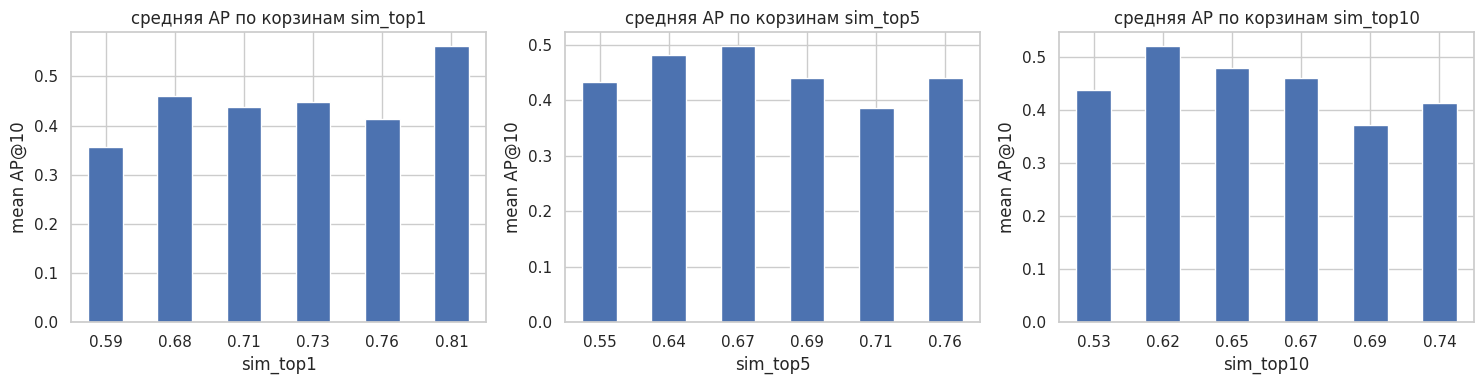

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, features):
    binned = feat.groupby(pd.qcut(feat[f], 6, duplicates="drop"),
                          observed=True)["ap_rosberta"].mean()
    binned.plot.bar(ax=ax, color="#4C72B0")
    ax.set_title(f"средняя AP по корзинам {f}")
    ax.set_xlabel(f); ax.set_ylabel("mean AP@10")
    ax.set_xticklabels([f"{iv.mid:.2f}" for iv in binned.index], rotation=0)
plt.tight_layout(); plt.show()

### 6.3 Близость у провальных (AP=0) vs остальных запросов

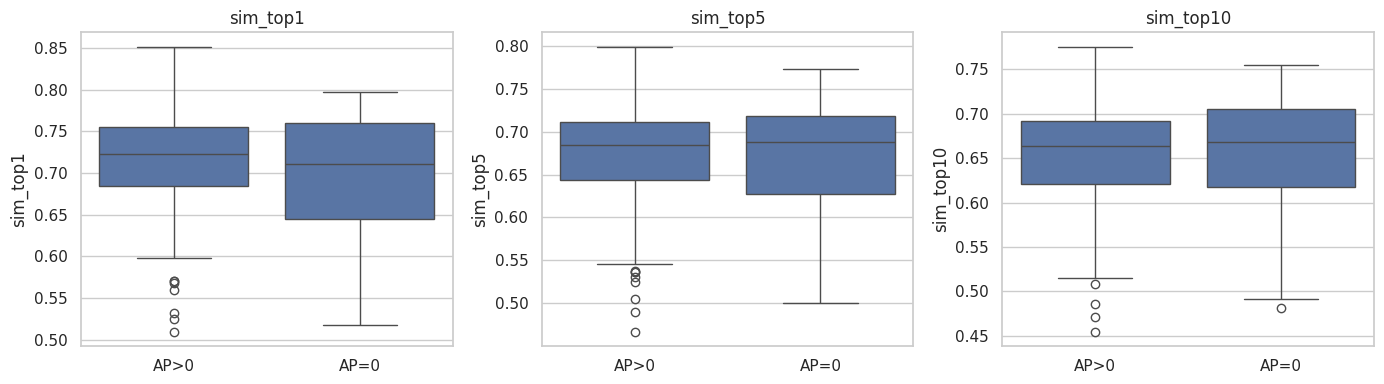

Точечно-бисериальная корреляция (признак vs индикатор AP=0):
  sim_top1        r=-0.124  p=5.6e-03
  sim_top5        r=-0.067  p=1.4e-01
  sim_top10       r=-0.027  p=5.5e-01

Медиана признака: AP=0 vs AP>0
     sim_top1  sim_top5  sim_top10
ap0                               
0       0.723     0.684      0.664
1       0.711     0.688      0.668


In [11]:
feat["ap0"] = (feat["ap_rosberta"] == 0).astype(int)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, f in zip(axes, features):
    sns.boxplot(data=feat, x="ap0", y=f, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["AP>0", "AP=0"]); ax.set_xlabel("")
    ax.set_title(f)
plt.tight_layout(); plt.show()

print("Точечно-бисериальная корреляция (признак vs индикатор AP=0):")
for f in features:
    r = stats.pointbiserialr(feat["ap0"], feat[f])
    print(f"  {f:15s} r={r.statistic:+.3f}  p={r.pvalue:.1e}")
print("\nМедиана признака: AP=0 vs AP>0")
print(feat.groupby("ap0")[features].median().round(3))

### 6.4 Контроль на число правильных статей (`n_gt`)

AP зависит от `n_gt`. Проверяем связь **внутри одноответных запросов** (`n_gt=1`),
чтобы исключить этот конфаундер.

In [12]:
sub = feat[feat["n_gt"] == 1]
print(f"одноответных запросов (n_gt=1): {len(sub)}")
for f in features:
    sp = stats.spearmanr(sub[f], sub["ap_rosberta"])
    print(f"  Spearman({f:15s}, AP) = {sp.statistic:+.3f}  (p={sp.pvalue:.1e})")

одноответных запросов (n_gt=1): 279
  Spearman(sim_top1       , AP) = +0.141  (p=1.8e-02)
  Spearman(sim_top5       , AP) = +0.009  (p=8.8e-01)
  Spearman(sim_top10      , AP) = -0.021  (p=7.3e-01)


### 6.5 Вывод по гипотезе

*(заполняется по числам выше)*

- Значимая положительная Spearman-корреляция + монотонная калибровочная кривая ⇒
  близость **является сигналом уверенности**: чем ближе топовая статья, тем выше AP.
- Тогда `sim_top1` / `margin` можно использовать как **фичу уверенности** (детектор
  вероятных провалов, вход для обучаемого ранжировщика, триггер смены стратегии).
- Если корреляция слабая/незначимая — dense-близость про качество выдачи не говорит,
  и опираться на неё как на конфиденс нельзя.